# Article figures — reproducible source code

**Author:** [Your Name] · Companion to *Leakage-Aware Deep Learning for Coffee and Cocoa Disease Diagnosis* (Cureus J Comput Sci).

This notebook contains the exact plotting code for each figure of the article, with the figure rendered inline as the cell output. Figures 1 and 3–7 are self-contained (they use the reported values from Tables 2, 3, 5 and 6, so they run standalone and reproduce the published figures). Figure 2 (near-duplicate pairs) is produced by the deduplication-audit cell of `coffee_classification_dinov2.ipynb` and requires the JMuBEN images; its rendered result is embedded below. Figures 8 and 9 (cocoa detection examples) are produced by `cocoa_detection_yolov11.ipynb`.

Run the setup cell first, then any figure cell.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
plt.rcParams.update({'font.size':12,'font.family':'DejaVu Sans','axes.grid':True,
                     'grid.alpha':0.3,'axes.axisbelow':True})
BLUE, ORANGE, GREEN, RED, GREY = '#2f6fb2','#e08a1e','#3a9d54','#c0392b','#7f8c8d'
classes = ['Healthy','Leaf-miner','Phoma','Rust']


## Figure 1 — Class distribution per split

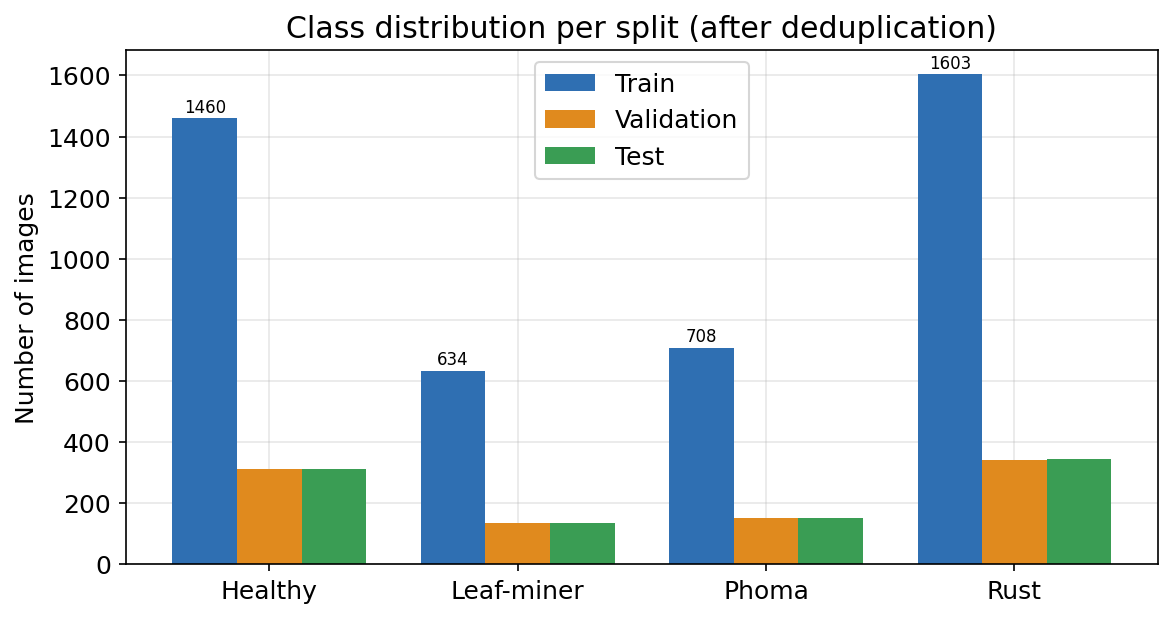

In [2]:
# FIGURE 1 — Class distribution per split (after deduplication)
# Values are the retained-image counts from Table 2.
tr=[1460,634,708,1603]; va=[313,136,152,343]; te=[313,136,152,344]
x=np.arange(4); w=0.26
fig,ax=plt.subplots(figsize=(8,4.3))
ax.bar(x-w,tr,w,label='Train',color=BLUE); ax.bar(x,va,w,label='Validation',color=ORANGE); ax.bar(x+w,te,w,label='Test',color=GREEN)
for i,v in enumerate(tr): ax.text(i-w,v+20,str(v),ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(classes); ax.set_ylabel('Number of images')
ax.set_title('Class distribution per split (after deduplication)'); ax.legend()
plt.tight_layout(); plt.show()


## Figure 2 — Deduplication audit: near-duplicate pairs (JMuBEN)

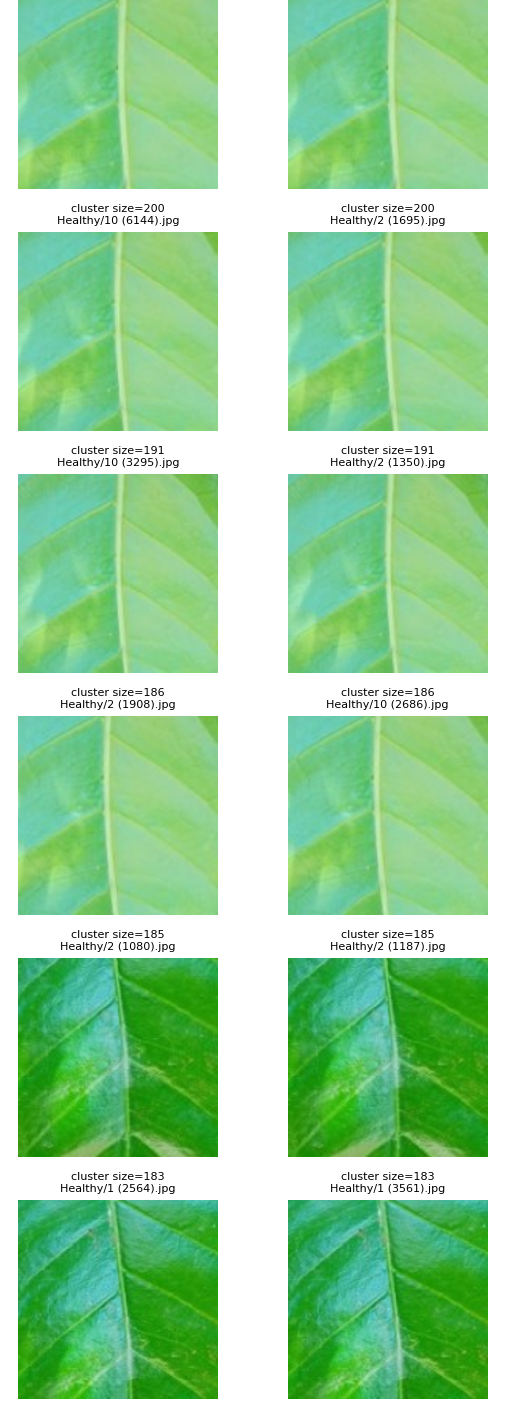

In [ ]:
# FIGURE 2 — Deduplication audit: representative near-duplicate pairs in JMuBEN
# This is the authentic source cell from coffee_classification_dinov2.ipynb.
# It detects exact-dHash duplicate clusters in the JMuBEN (DS5) images and renders
# the six representative near-duplicate pairs shown as Figure 2. It requires the
# JMuBEN images on Drive and the earlier pipeline variables (all_raw, hash_image,
# SEED, TARGET_CLASSES). The rendered result is shown below.

# DEDUP AUDIT  ─────────────────────────────────────────
# Compute dHash 17x16 for ALL raw images (for illustration). For large datasets
# you can subsample if needed.
import random as _rnd

DEDUP_AUDIT_SAMPLES = 6000   # cap the number of images analyzed if raw is too large
AUDIT_SOURCE_FILTER = 'DS5'  # JMuBEN — where dedup removes 97%

raw_audit = [s for s in all_raw if s[2] == AUDIT_SOURCE_FILTER]
if len(raw_audit) > DEDUP_AUDIT_SAMPLES:
    _rnd.seed(SEED)
    raw_audit = _rnd.sample(raw_audit, DEDUP_AUDIT_SAMPLES)
print(f'Audit on {AUDIT_SOURCE_FILTER}: {len(raw_audit):,} images')

# Hash all (path, label) and store the dHash bytes
def _bits_from_dh(dh_bytes):
    return np.unpackbits(np.frombuffer(dh_bytes, dtype=np.uint8))

audit_paths, audit_bits = [], []
for path, _, _ in tqdm(raw_audit, desc='Audit hash'):
    _, dh = hash_image(path)
    if dh is None: continue
    audit_paths.append(path)
    audit_bits.append(_bits_from_dh(dh))
audit_bits = np.stack(audit_bits, axis=0).astype(np.uint8)
print(f'Hash matrix: {audit_bits.shape}  (n_imgs, 272 bits)')

# Sample random pairs and compute Hamming distance distribution
N_PAIRS = 200_000
_rnd.seed(SEED)
n = audit_bits.shape[0]
i_a = np.random.randint(0, n, size=N_PAIRS)
i_b = np.random.randint(0, n, size=N_PAIRS)
ok  = i_a != i_b
i_a, i_b = i_a[ok], i_b[ok]
ham = np.count_nonzero(audit_bits[i_a] != audit_bits[i_b], axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ham, bins=80, color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', ls='--', label='exact match (current threshold)')
for thr in [5, 10, 20]:
    ax.axvline(thr, color='orange', ls=':', alpha=0.6,
               label=f'<= {thr} bits' if thr == 5 else None)
ax.set_xlabel('Hamming distance (out of 272 bits)')
ax.set_ylabel('Pair count')
ax.set_title(f'Pair-wise Hamming distance on {AUDIT_SOURCE_FILTER} '
             f'({len(ham):,} random pairs)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/coffee_outputs/fig_dedup_hamming.png', dpi=160, bbox_inches='tight')
plt.show()

# Cluster images by exact dHash (computed over ALL audit_paths, not the subsampled pairs)
from collections import defaultdict
cluster = defaultdict(list)
for p, bits in zip(audit_paths, audit_bits):
    key = bits.tobytes()
    cluster[key].append(p)
sizes = sorted([(len(v), k) for k, v in cluster.items()], reverse=True)
print(f'\nTop 10 largest clusters (images sharing the same dHash):')
for sz, k in sizes[:10]:
    print(f'  cluster size = {sz}')

# Visualise 6 representative duplicate pairs (Hamming = 0)
n_show = min(6, sum(1 for sz, _ in sizes if sz >= 2))
shown = 0
fig, axes = plt.subplots(n_show, 2, figsize=(6, 2.5 * n_show))
if n_show == 1: axes = axes.reshape(1, 2)
for sz, k in sizes:
    if sz < 2 or shown >= n_show: break
    p1, p2 = cluster[k][0], cluster[k][1]
    for j, p in enumerate([p1, p2]):
        try:
            img = Image.open(p).convert('RGB').resize((180, 180))
            axes[shown, j].imshow(img)
        except Exception: pass
        axes[shown, j].axis('off')
        axes[shown, j].set_title(f'cluster size={sz}\n{p.parent.name}/{p.name[:18]}',
                                 fontsize=8)
    shown += 1
fig.suptitle(f'6 representative duplicate pairs ({AUDIT_SOURCE_FILTER}, dHash exact match)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/coffee_outputs/fig_dedup_pairs.png', dpi=160, bbox_inches='tight')
plt.show()

# Summary
n0    = int((ham == 0).sum())
n_le5 = int((ham <= 5).sum())
print(f'\nAudit summary ({AUDIT_SOURCE_FILTER}):')
print(f'  Hamming == 0   (current dedup) : {n0:>7,}  ({n0/len(ham)*100:.2f}%)')
print(f'  Hamming <= 5   (stricter)      : {n_le5:>7,}  ({n_le5/len(ham)*100:.2f}%)')
print(f'  Median Hamming = {int(np.median(ham))} bits, P95 = {int(np.percentile(ham,95))}')
print(f'  -> If Hamming<=5 is a more reasonable threshold, conclusion: {AUDIT_SOURCE_FILTER} really has many internal near-duplicates.')


## Figure 3 — Method comparison (macro-F1 with 95% CI)

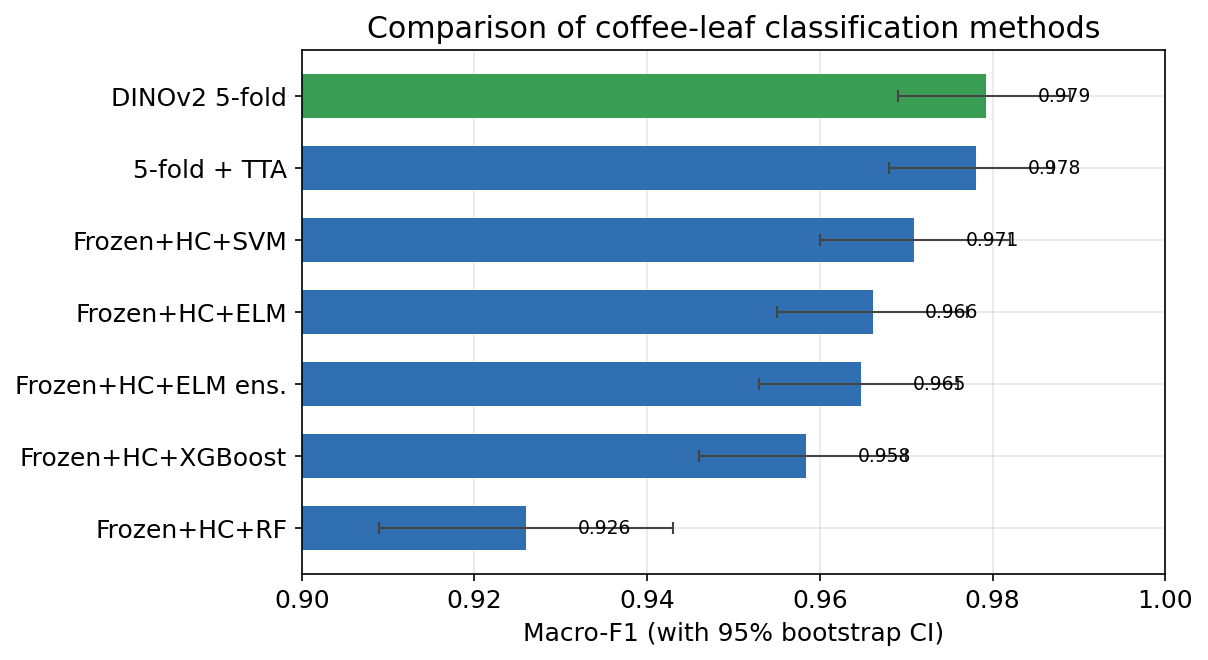

In [3]:
# FIGURE 3 — Comparison of the seven classifiers (macro-F1 + 95% bootstrap CI, Table 2)
meth=['DINOv2 5-fold','5-fold + TTA','Frozen+HC+SVM','Frozen+HC+ELM','Frozen+HC+ELM ens.','Frozen+HC+XGBoost','Frozen+HC+RF']
f1=[0.9792,0.9781,0.9709,0.9662,0.9648,0.9584,0.9260]
lo=[0.969,0.968,0.960,0.955,0.953,0.946,0.909]; hi=[0.989,0.987,0.982,0.977,0.976,0.970,0.943]
err=[np.array(f1)-np.array(lo), np.array(hi)-np.array(f1)]
cols=[GREEN]+[BLUE]*6; y=np.arange(len(meth))[::-1]
fig,ax=plt.subplots(figsize=(8.2,4.6))
ax.barh(y,f1,xerr=err,color=cols,capsize=3,height=0.62,error_kw={'elinewidth':1,'ecolor':'#444'})
for yy,v in zip(y,f1): ax.text(v+0.006,yy,f'{v:.3f}',va='center',fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(meth); ax.set_xlim(0.90,1.0)
ax.set_xlabel('Macro-F1 (with 95% bootstrap CI)'); ax.set_title('Comparison of coffee-leaf classification methods')
plt.tight_layout(); plt.show()


## Figure 4 — Confusion matrix (5-fold ensemble + TTA)

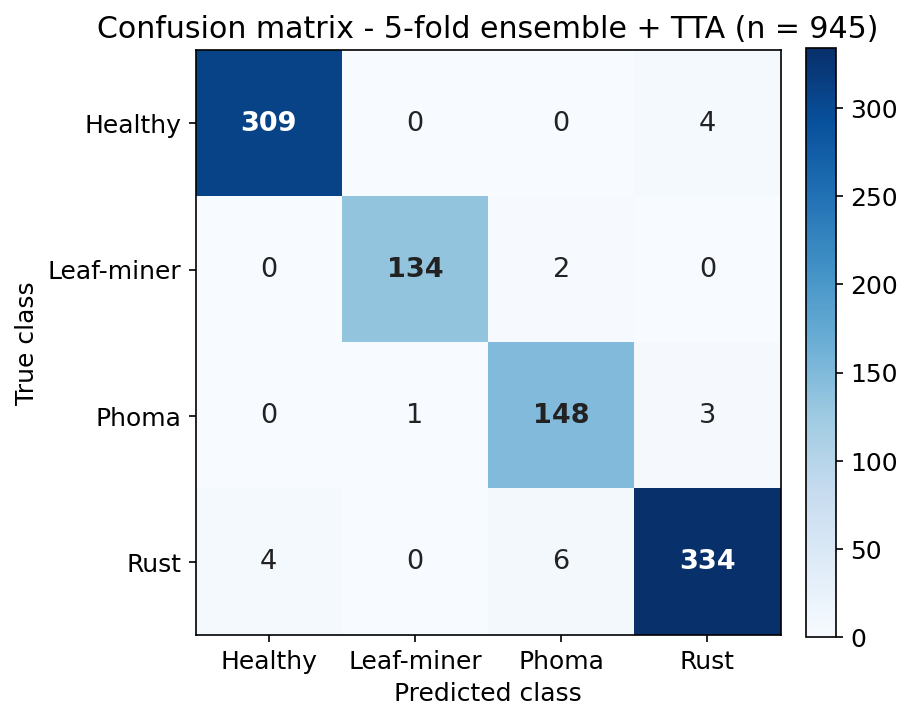

In [4]:
# FIGURE 4 — Confusion matrix (5-fold ensemble + TTA, n=945)
# Reconstructed from the per-class precision/recall of Table 3 and the Phoma error breakdown.
cm=np.array([[309,0,0,4],[0,134,2,0],[0,1,148,3],[4,0,6,334]])
fig,ax=plt.subplots(figsize=(6,5.2)); im=ax.imshow(cm,cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xticklabels(classes); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class'); ax.set_title('Confusion matrix - 5-fold ensemble + TTA (n = 945)')
thr=cm.max()/2
for i in range(4):
    for j in range(4):
        ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>thr else '#222',fontsize=13,fontweight='bold' if i==j else 'normal')
ax.grid(False); fig.colorbar(im,fraction=0.046,pad=0.04); plt.tight_layout(); plt.show()


## Figure 5 — Per-class precision / recall / F1

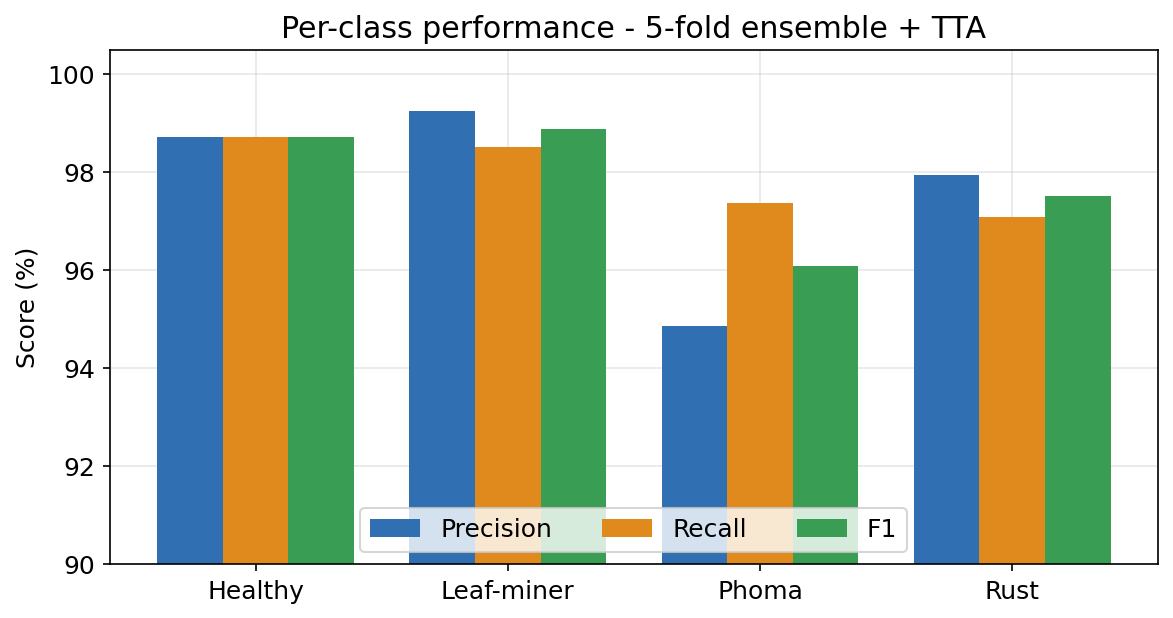

In [5]:
# FIGURE 5 — Per-class precision / recall / F1 (Table 3)
P=[98.72,99.26,94.87,97.95]; R=[98.72,98.53,97.37,97.09]; F=[98.72,98.89,96.10,97.52]
x=np.arange(4); w=0.26
fig,ax=plt.subplots(figsize=(8,4.3))
ax.bar(x-w,P,w,label='Precision',color=BLUE); ax.bar(x,R,w,label='Recall',color=ORANGE); ax.bar(x+w,F,w,label='F1',color=GREEN)
ax.set_xticks(x); ax.set_xticklabels(classes); ax.set_ylim(90,100.5); ax.set_ylabel('Score (%)')
ax.set_title('Per-class performance - 5-fold ensemble + TTA'); ax.legend(ncol=3,loc='lower center')
plt.tight_layout(); plt.show()


## Figure 6 — Accuracy vs. latency trade-off

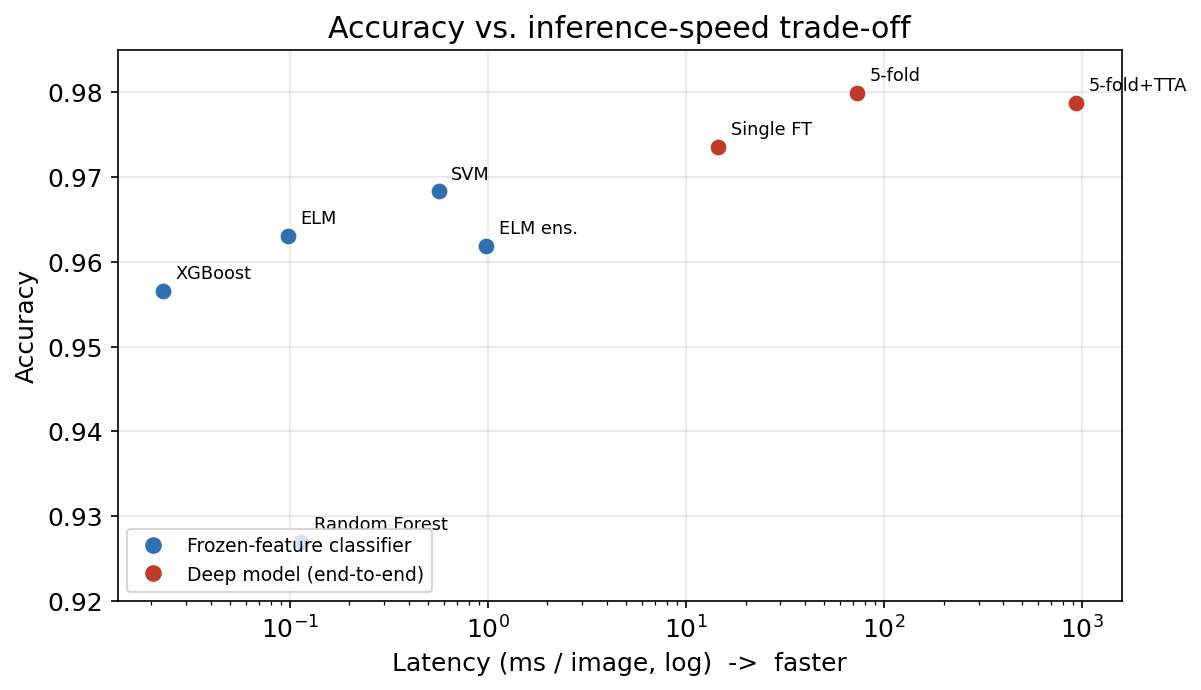

In [6]:
# FIGURE 6 — Accuracy vs inference-latency trade-off (Table 5)
lbl=['XGBoost','ELM','Random Forest','SVM','ELM ens.','Single FT','5-fold','5-fold+TTA']
ms=[0.023,0.098,0.114,0.566,0.980,14.6,73.1,930.7]
acc=[0.9566,0.9630,0.9270,0.9683,0.9619,0.9735,0.9799,0.9788]
kind=['f']*5+['d']*3
fig,ax=plt.subplots(figsize=(8.2,4.8))
for m,a,l,k in zip(ms,acc,lbl,kind):
    ax.scatter(m,a,s=70,color=(BLUE if k=='f' else RED),zorder=3,edgecolor='white',linewidth=0.8)
    ax.annotate(l,(m,a),textcoords='offset points',xytext=(6,6),fontsize=8.5)
ax.set_xscale('log'); ax.set_xlabel('Latency (ms / image, log)  ->  faster'); ax.set_ylabel('Accuracy'); ax.set_ylim(0.92,0.985)
ax.set_title('Accuracy vs. inference-speed trade-off')
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=BLUE,label='Frozen-feature classifier',markersize=9),
                   Line2D([0],[0],marker='o',color='w',markerfacecolor=RED,label='Deep model (end-to-end)',markersize=9)],loc='lower left',fontsize=9)
plt.tight_layout(); plt.show()


## Figure 7 — Cocoa-pod detection: mAP per class

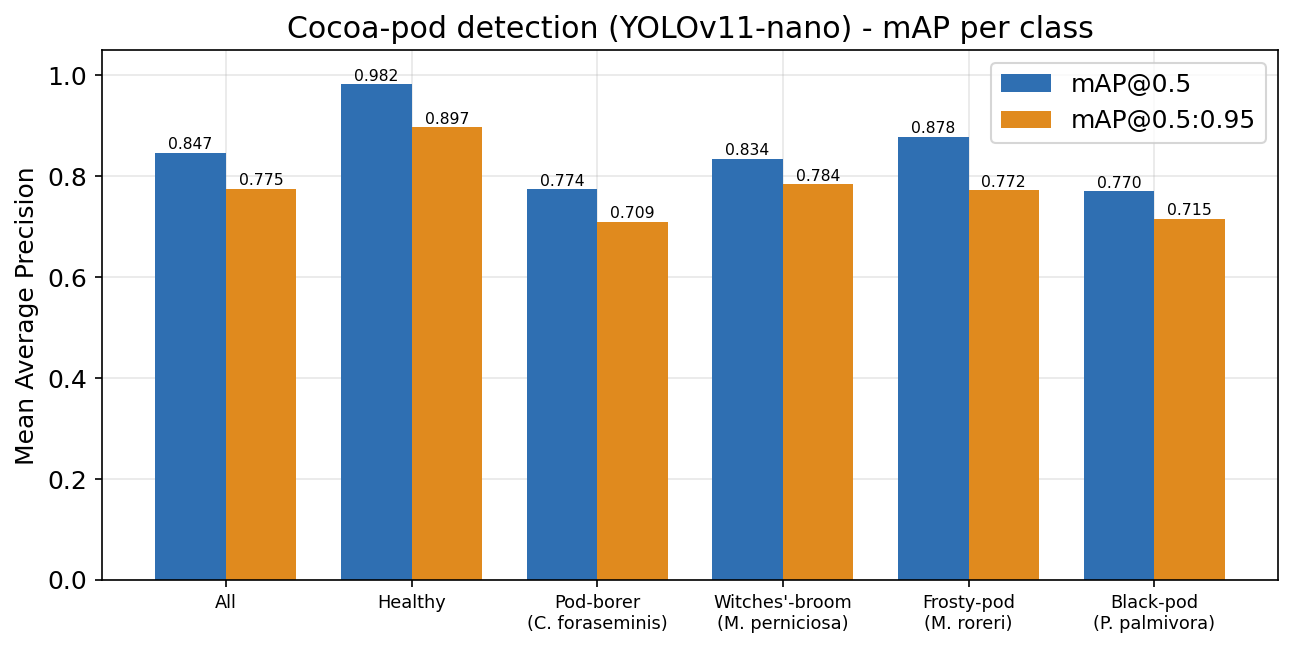

In [7]:
# FIGURE 7 — Cocoa-pod detection: mAP per class (YOLOv11-nano, Table 6)
cc=['All','Healthy','Pod-borer\n(C. foraseminis)',"Witches'-broom\n(M. perniciosa)",'Frosty-pod\n(M. roreri)','Black-pod\n(P. palmivora)']
m50=[0.847,0.982,0.774,0.834,0.878,0.770]; m5095=[0.775,0.897,0.709,0.784,0.772,0.715]
x=np.arange(len(cc)); w=0.38
fig,ax=plt.subplots(figsize=(8.8,4.5))
b1=ax.bar(x-w/2,m50,w,label='mAP@0.5',color=BLUE); b2=ax.bar(x+w/2,m5095,w,label='mAP@0.5:0.95',color=ORANGE)
for b in list(b1)+list(b2): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.008,f'{b.get_height():.3f}',ha='center',fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(cc,fontsize=8.5); ax.set_ylim(0,1.05); ax.set_ylabel('Mean Average Precision')
ax.set_title('Cocoa-pod detection (YOLOv11-nano) - mAP per class'); ax.legend()
plt.tight_layout(); plt.show()


## Figures 8 and 9 — Cocoa detection examples

These are produced by `cocoa_detection_yolov11.ipynb` (model inference on a dataset image and on an external image). They are shown inline in that notebook. Representative renders are embedded below for reference.

In [ ]:
# Source: cocoa_detection_yolov11.ipynb (YOLOv11 inference)
# Figure 8 — detection on a dataset image


**Figure 8** — detection on an dataset image (source: `cocoa_detection_yolov11.ipynb`).

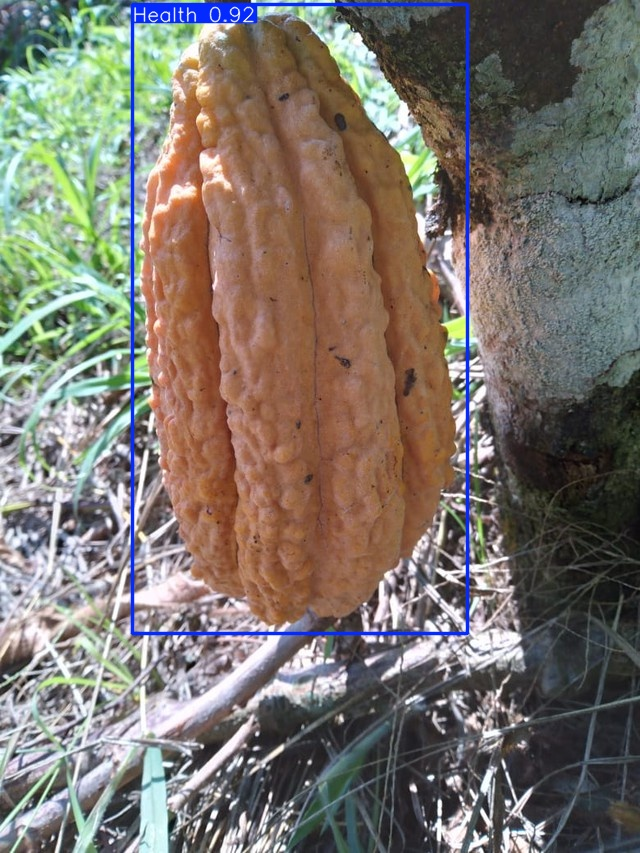

In [ ]:
# Figure 8: rendered by cocoa_detection_yolov11.ipynb (model.predict + display)


**Figure 9** — detection on an external internet image (source: `cocoa_detection_yolov11.ipynb`).

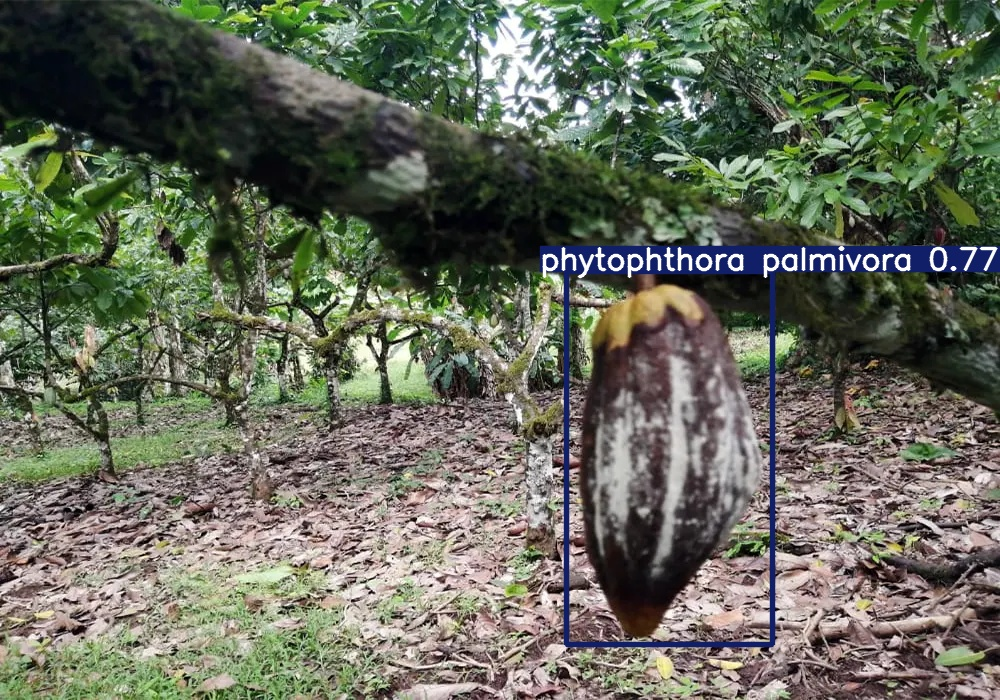

In [ ]:
# Figure 9: rendered by cocoa_detection_yolov11.ipynb (model.predict + display)
